In [ ]:
#!pip install gstools
#!pip install georasters
# !pip install geemap
#!pip install pingouin
#!pip install geopandas
from google.colab import drive
import io
import sys
from contextlib import redirect_stdout
import os
os.environ['USE_PYGEOS'] = '0'
with io.StringIO() as buf, redirect_stdout(buf):
   drive.mount('/content/drive')
   output = buf.getvalue()

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
#import gstools as gs
import matplotlib.pyplot as plt
# import ee
# import geemap
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
#import tensorflow as tf
#from tensorflow import keras
#from tensorflow.keras import layers
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
#from google.colab import drive
#drive.mount('/content/drive')
#ee.Authenticate()
#ee.Initialize(project='ee-jolejua')

# Alistamiento de datos para correlaciones

Se corre cuando se tiene una nueva base de datos para alistar el archivo, sólo se debe hacer una vez, y dicho archivo queda guardado, mostrandose en el siguiente bloque

<Axes: >

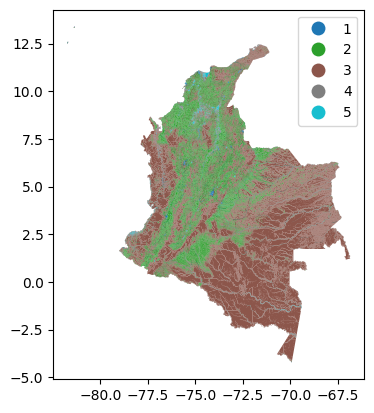

In [ ]:
dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/Cobertura_de_la_tierra_100K_Periodo_2020_limite_administrativo/shape Limite admin/e_cobertura_tierra_2020_admin.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
dfg.plot('nivel_1',legend=True)

In [ ]:
dfg.columns

Index(['OBJECTID', 'codigo', 'leyenda', 'insumo', 'apoyo', 'confiabili',
       'cambio', 'nivel_1', 'nivel_2', 'nivel_3', 'nivel_4', 'nivel_5',
       'nivel_6', 'area_ha', 'nom_dpto', 'nom_mpio', 'Cod_dane_m', 'Categoria',
       'Cod_dane_d', 'cod_aa', 'nom_aa', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')

In [ ]:
mydict1={'1':'1. Territorios artificializados','2':'2. Territorios agrícolas','3':'3. Bosques y áreas seminaturales','4':'4. Áreas húmedas','5':'5. Superficies de agua'}
mydict1

{'1': '1. Territorios artificializados',
 '2': '2. Territorios agrícolas',
 '3': '3. Bosques y áreas seminaturales',
 '4': '4. Áreas húmedas',
 '5': '5. Superficies de agua'}

In [ ]:
import csv

with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/Nivel3.csv', mode='r') as infile:
    reader = csv.reader(infile)
    with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/N3.csv', mode='w') as outfile:
        writer = csv.writer(outfile)
        mydict = {rows[1]:rows[0] for rows in reader}
mydict

{'111': '1.1.1. Tejido urbano continuo',
 '112': '1.1.2. Tejido urbano discontinuo',
 '121': '1.2.1. Zonas industriales o comerciales',
 '122': '1.2.2. Red vial, ferroviaria y terrenos asociados',
 '123': '1.2.3. Zonas portuarias',
 '124': '1.2.4. Aeropuertos',
 '125': '1.2.5. Obras hidráulicas',
 '131': '1.3.1. Zonas de extracción minera',
 '132': '1.3.2. Zona de disposición de residuos',
 '141': '1.4.1. Zonas verdes urbanas',
 '142': '1.4.2. Instalaciones recreativas',
 '211': '2.1.1. Otros cultivos transitorios',
 '212': '2.1.2. Cereales',
 '213': '2.1.3. Oleaginosas y leguminosas',
 '214': '2.1.4. Hortalizas',
 '215': '2.1.5. Tubérculos',
 '221': '2.2.1. Cultivos permanentes herbáceos',
 '222': '2.2.2. Cultivos permanentes arbustivos',
 '223': '2.2.3. Cultivos permanentes arbóreos',
 '224': '2.2.4. Cultivos agroforestales',
 '225': '2.2.5. Cultivos confinados',
 '231': '2.3.1. Pastos limpios',
 '232': '2.3.2. Pastos arbolados',
 '233': '2.3.3. Pastos enmalezados',
 '241': '2.4.1. M

In [ ]:
dfg['Leyenda_1']=dfg['nivel_1'].map(mydict1)
dfg[['Leyenda_1','nivel_1']]

,Leyenda_1,nivel_1
0,3. Bosques y áreas seminaturales,3
1,3. Bosques y áreas seminaturales,3
2,3. Bosques y áreas seminaturales,3
3,3. Bosques y áreas seminaturales,3
4,3. Bosques y áreas seminaturales,3
...,...,...
393463,3. Bosques y áreas seminaturales,3
393464,3. Bosques y áreas seminaturales,3
393465,2. Territorios agrícolas,2
393466,2. Territorios agrícolas,2


In [ ]:
dfg['Leyenda_3']=dfg['nivel_3'].map(mydict)
dfg[['Leyenda_3','nivel_3']]

,Leyenda_3,nivel_3
0,3.2.1. Herbazal,321
1,3.2.3. Vegetación secundaria o en transición,323
2,3.1.1. Bosque denso,311
3,3.2.3. Vegetación secundaria o en transición,323
4,3.1.1. Bosque denso,311
...,...,...
393463,3.1.1. Bosque denso,311
393464,3.1.1. Bosque denso,311
393465,2.3.1. Pastos limpios,231
393466,2.3.1. Pastos limpios,231


In [ ]:
encoded_df = pd.get_dummies(dfg, columns=["Leyenda_3"])  # Encode the "leyenda 3" column
encoded_df1 = pd.get_dummies(dfg, columns=["Leyenda_1"])  # Encode the "Leyenda 1" column
#print(encoded_df1.columns)
encoded_df=pd.concat([encoded_df,encoded_df1[['Leyenda_1_1. Territorios artificializados', 'Leyenda_1_2. Territorios agrícolas', 'Leyenda_1_3. Bosques y áreas seminaturales','Leyenda_1_4. Áreas húmedas',
       'Leyenda_1_5. Superficies de agua']]], axis=1)
encoded_df['groupb']=0
encoded_df

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,groupb
0,1.0,321122,3.2.1.1.2.2. Herbazal denso inundable arbolado,Landsat_2020_mediana_07042021,None,SI,2,3,32,321,...,False,False,False,False,False,False,True,False,False,0
1,2.0,3232,3.2.3.2. Vegetación secundaria baja,Landsat_2020_mediana_07042021,None,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
2,3.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,None,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
3,4.0,3231,3.2.3.1. Vegetación secundaria alta,Landsat_2020_mediana_07042021,None,SI,2,3,32,323,...,False,False,False,False,False,False,True,False,False,0
4,5.0,31111,3.1.1.1.1. Bosque denso alto de tierra firme,Landsat_2020_mediana_07042021,None,SI,2,3,31,311,...,False,False,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393463,393464.0,31112,3.1.1.1.2. Bosque denso alto inundable,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393464,393465.0,31112,3.1.1.1.2. Bosque denso alto inundable,"Landsat_2020_mediana_07042021, Landsat8_1159_0...",None,SI,1,3,31,311,...,False,False,False,False,False,False,True,False,False,0
393465,393466.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0
393466,393467.0,231,2.3.1. Pastos limpios,Landsat_2020_Mediana_07042021,GoogleEarth,SI,2,2,23,231,...,False,False,False,False,False,True,False,False,False,0


<Axes: xlabel='longitude', ylabel='latitude'>

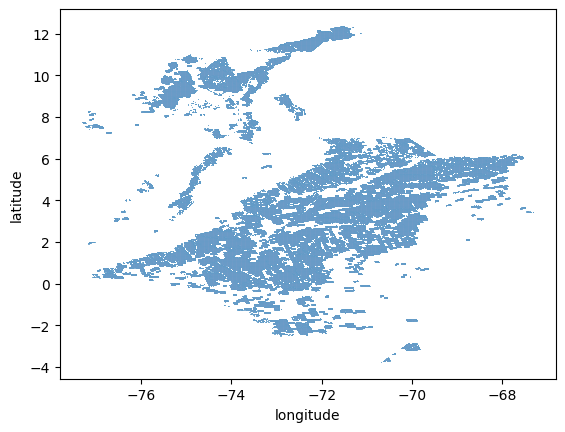

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_prom_2020_filtered.csv')
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')

In [ ]:
#df_s.groupby(['latitude','longitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')

In [ ]:
df_s

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28


In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
df_s

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]"
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]"
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]"
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]"
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]"
...,...,...,...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]"
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.44500000000001, 4.525]"
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]"
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]"


In [ ]:
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta

In [ ]:
l_in=list(encoded_df.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df[i]=encoded_df[i]*encoded_df['SHAPE_Area']
df_s.loc[:,l_in]=None
df_s['Leyenda_1_4. Áreas húmedas'][0]

/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
for j in df_s.index:
    #print(j)
    f=encoded_df[df_s['geometry'][j].intersects(encoded_df['geometry'])]
    f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    if not len(f1)==0:
        #print(j)
        for i in l_in:
            df_s.loc[j, i]=f1[i].iloc[0].copy()

KeyboardInterrupt: 

In [ ]:
df_s

,latitude,longitude,time,CH4_column_volume_mixing_ratio_dry_air,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-4.165,-69.995,1.693677e+12,1909.928716,[-69.995],[-4.165],"[-69.995, -4.165]","POLYGON ((-70.00500000000001 -4.175, -70.00500...",None,None,...,None,None,None,None,None,None,None,None,None,None
1,-4.155,-70.005,1.693677e+12,1909.928711,[-70.005],[-4.155],"[-70.005, -4.155]","POLYGON ((-70.015 -4.165, -70.015 -4.145000000...",None,None,...,None,None,None,None,None,None,None,None,None,None
2,-4.145,-70.015,1.708235e+12,1880.866934,[-70.015],[-4.1450000000000005],"[-70.015, -4.1450000000000005]","POLYGON ((-70.025 -4.155, -70.025 -4.135000000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
3,-4.145,-70.005,1.708235e+12,1880.867002,[-70.005],[-4.1450000000000005],"[-70.005, -4.1450000000000005]","POLYGON ((-70.015 -4.155, -70.015 -4.135000000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
4,-4.145,-69.995,1.722793e+12,1851.805167,[-69.995],[-4.1450000000000005],"[-69.995, -4.1450000000000005]","POLYGON ((-70.00500000000001 -4.155, -70.00500...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601972,12.445,-71.655,1.704000e+12,1934.657396,[-71.655],[12.445],"[-71.655, 12.445]","POLYGON ((-71.665 12.435, -71.665 12.455, -71....",0.0,0.0,...,0.0,0.0,0.000426,0.000601,0.0,0.0,0.0,0.0,0.000208,0.001027
601973,12.445,-71.645,1.704233e+12,1935.313772,[-71.645],[12.445],"[-71.645, 12.445]","POLYGON ((-71.655 12.435, -71.655 12.455, -71....",0.0,0.0,...,0.0,0.0,0.000426,0.000601,0.0,0.0,0.0,0.0,0.000208,0.001027
601974,12.445,-71.635,1.703882e+12,1934.936248,[-71.635],[12.445],"[-71.635, 12.445]","POLYGON ((-71.64500000000001 12.435, -71.64500...",0.0,0.0,...,0.0,0.0,0.0,0.000601,0.0,0.0,0.0,0.0,0.000208,0.000601
601975,12.455,-71.675,1.704120e+12,1930.317069,[-71.675],[12.455],"[-71.675, 12.455]","POLYGON ((-71.685 12.445, -71.685 12.465, -71....",0.0,0.0,...,0.0,0.0,0.0,0.000601,0.0,0.0,0.0,0.0,0.000061,0.000601


In [ ]:
#Eliminar zonas de agua para evitar glint

In [ ]:
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')

#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/glint_intersect.csv')

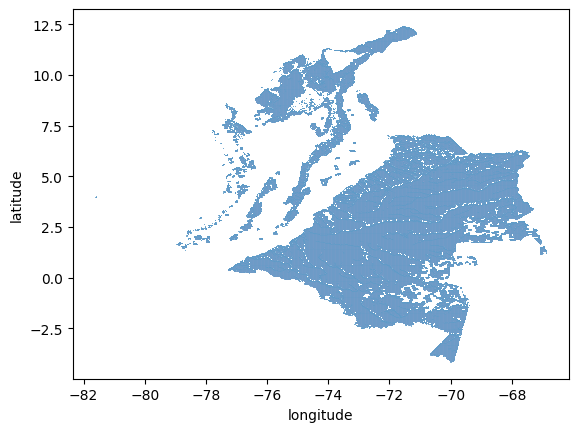

,coordinates
0,"[-69.995, -4.165]"
1,"[-70.005, -4.155]"
12,"[-69.965, -4.135]"
13,"[-69.955, -4.135]"
14,"[-69.94500000000001, -4.135]"
...,...
601920,"[-71.58500000000001, 12.415]"
601921,"[-71.575, 12.415]"
601940,"[-71.605, 12.425]"
601941,"[-71.595, 12.425]"


# Análisis de correlaciones

In [ ]:
df_corr=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020_old.csv',index_col=0)
df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]#+

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001214,0.288801,0.0,0.0
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.002290,0.293556,0.0,0.0
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001139,0.292049,0.0,0.0
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000213,0.288675,0.0,0.0
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000204,0.293148,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000212,0.029261,0.0,0.0
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.019897,0.0,0.0
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000081,0.025519,0.0,0.0
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000032,0.020053,0.0,0.0


,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001214,0.288801,0.0,0.0
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.002290,0.293556,0.0,0.0
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.001139,0.292049,0.0,0.0
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,0.0,0.000006,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000213,0.288675,0.0,0.0
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000204,0.293148,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000212,0.029261,0.0,0.0
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.019897,0.0,0.0
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000081,0.025519,0.0,0.0
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000032,0.020053,0.0,0.0


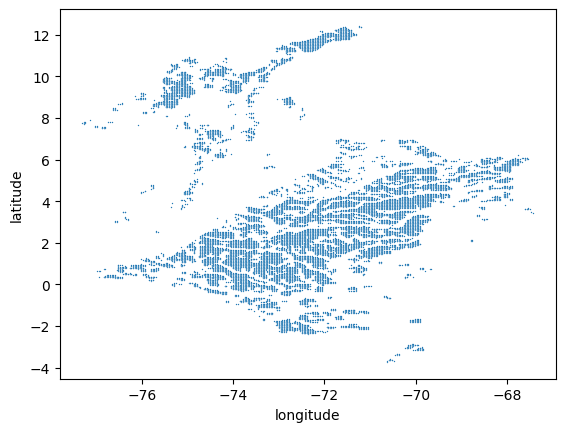

In [ ]:
df_corr=df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]
sns.scatterplot(data=df_corr,x='longitude',y='latitude',s=1)
df_corr

In [ ]:
l_in=list(df_corr.columns)
#l_in.remove(['longitude', 'latitude','CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 'coordinate_x','coordinate_y', 'coordinates', 'geometry'])
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in

['Leyenda_3_1.1.1. Tejido urbano continuo',
 'Leyenda_3_1.1.2. Tejido urbano discontinuo',
 'Leyenda_3_1.2.1. Zonas industriales o comerciales',
 'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
 'Leyenda_3_1.2.3. Zonas portuarias',
 'Leyenda_3_1.2.4. Aeropuertos',
 'Leyenda_3_1.2.5. Obras hidráulicas',
 'Leyenda_3_1.3.1. Zonas de extracción minera',
 'Leyenda_3_1.3.2. Zona de disposición de residuos',
 'Leyenda_3_1.4.1. Zonas verdes urbanas',
 'Leyenda_3_1.4.2. Instalaciones recreativas',
 'Leyenda_3_2.1.1. Otros cultivos transitorios',
 'Leyenda_3_2.1.2. Cereales',
 'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
 'Leyenda_3_2.1.4. Hortalizas',
 'Leyenda_3_2.1.5. Tubérculos',
 'Leyenda_3_2.2.1. Cultivos permanentes herbáceos',
 'Leyenda_3_2.2.2. Cultivos permanentes arbustivos',
 'Leyenda_3_2.2.3. Cultivos permanentes arbóreos',
 'Leyenda_3_2.2.4. Cultivos agroforestales',
 'Leyenda_3_2.2.5. Cultivos confinados',
 'Leyenda_3_2.3.1. Pastos limpios',
 'Leyenda_3_2.3.2. Past

In [ ]:
correlaciones=df_corr.corr(numeric_only=True)['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
correlaciones

,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
longitude,-0.167609
latitude,0.467819
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,1.000000
Leyenda_3_1.1.1. Tejido urbano continuo,0.053854
Leyenda_3_1.1.2. Tejido urbano discontinuo,0.080836
...,...
Leyenda_1_1. Territorios artificializados,0.079865
Leyenda_1_2. Territorios agrícolas,0.195299
Leyenda_1_3. Bosques y áreas seminaturales,-0.504060
Leyenda_1_4. Áreas húmedas,NaN


In [ ]:
print(len(correlaciones))
correlaciones.sort_values(ascending=False).head(10)


63


,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,1.000000
latitude,0.467819
Leyenda_3_2.4.4. Mosaico de pastos con espacios naturales,0.301007
Leyenda_3_2.3.3. Pastos enmalezados,0.296781
Leyenda_3_3.1.4. Bosque de galería y ripario,0.238221
Leyenda_1_2. Territorios agrícolas,0.195299
Leyenda_3_3.2.1. Herbazal,0.191339
Leyenda_3_2.3.1. Pastos limpios,0.183081
Leyenda_3_2.3.2. Pastos arbolados,0.173860
Leyenda_3_2.4.2. Mosaico de pastos y cultivos,0.173597


In [ ]:
d={}
for i in l_in:
    #df_filtered = df_corr[df_corr[i] >1e-15]
    df_corr.loc[df_corr[i] ==0, i] = np.nan
    #transformed, lambda_ = stats.boxcox(df_corr[i])
    #cor=df_filtered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].corr(df_filtered[i])
    #d[i]=cor
    sns.scatterplot(x=i,y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected',data=df_corr)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
corr_final=pg.pairwise_corr(df_corr,columns=[['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'],l_in])
corr_final.sort_values(by=['p-unc'])[['X', 'Y', 'n', 'r', 'p-unc','BF10']].head(60)

,X,Y,n,r,p-unc,BF10
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,13764,-0.503903,0.000000e+00,inf
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,9674,-0.429807,0.000000e+00,inf
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,4246,0.250185,1.318989e-61,6.668e+57
37,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_2. Territorios agrícolas,8165,0.134572,2.627021e-34,3.38e+30
29,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.1. Herbazal,5123,0.163864,3.652761e-32,3.152e+28
22,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.4.4. Mosaico de pastos con espacio...,6531,0.144601,7.454791e-32,1.381e+28
16,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.1. Pastos limpios,6894,0.108574,1.567000e-19,8.327e+15
31,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.3. Vegetación secundaria o en tr...,6308,0.091624,3.078128e-13,5.475e+09
27,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.4. Bosque de galería y ripario,5615,-0.093639,2.056707e-12,8.993e+08
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,1127,-0.202272,7.187647e-12,5.742e+08


In [ ]:
df_sorted = corr_final.reindex(corr_final['r'].abs().sort_values(ascending=False).index)
df_sorted#[(df_sorted['p-unc']<0.01)*(df_sorted['n']>20)].head(60)

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.1. Zonas verdes urbanas,pearson,two-sided,15,-0.355549,"[-0.73, 0.19]",1.934055e-01,0.693,0.262824
8,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.2. Instalaciones recreativas,pearson,two-sided,34,0.354059,"[0.02, 0.62]",3.994065e-02,1.616,0.550354
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.4. Cultivos agroforestales,pearson,two-sided,31,0.202910,"[-0.16, 0.52]",2.736196e-01,0.396,0.196642
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000
11,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.3. Oleaginosas y leguminosas,pearson,two-sided,60,-0.179058,"[-0.41, 0.08]",1.710323e-01,0.402,0.279971


In [ ]:
#dfg.groupby('nivel_3').nunique()['leyenda']

In [ ]:
df_corr.loc[df_corr['Leyenda_1_2. Territorios agrícolas'] !=0 ]

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.309013,7.743478,1866.559633,[-77.30901335132603],[7.7434777491102755],"[-77.30901335132603, 7.7434777491102755]",POLYGON ((-77.34494635132603 7.707544749110275...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.001214,0.288801,NaN,NaN
1,-77.273081,7.707545,1866.559612,[-77.27308073996124],[7.707545137745495],"[-77.27308073996124, 7.707545137745495]",POLYGON ((-77.30901373996124 7.671612137745495...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002290,0.293556,NaN,NaN
2,-77.273081,7.743478,1866.559570,[-77.27308073996124],[7.7434777491102755],"[-77.27308073996124, 7.7434777491102755]",POLYGON ((-77.30901373996124 7.707544749110275...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.001139,0.292049,NaN,NaN
3,-77.273081,7.779410,1866.559604,[-77.27308073996124],[7.779410360475056],"[-77.27308073996124, 7.779410360475056]",POLYGON ((-77.30901373996124 7.743477360475056...,NaN,0.000006,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.000213,0.288675,NaN,NaN
6,-77.237148,7.743478,1866.559606,[-77.23714812859646],[7.7434777491102755],"[-77.23714812859646, 7.7434777491102755]",POLYGON ((-77.27308112859646 7.707544749110275...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000204,0.293148,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25565,-67.535343,3.683093,1871.177431,[-67.53534306010563],[3.6830926648900384],"[-67.53534306010563, 3.6830926648900384]",POLYGON ((-67.57127606010563 3.647159664890038...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000212,0.029261,NaN,NaN
25566,-67.535343,6.018712,1876.836449,[-67.53534306010563],[6.018712403600794],"[-67.53534306010563, 6.018712403600794]",POLYGON ((-67.57127606010563 5.982779403600794...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019897,NaN,NaN
25567,-67.499410,3.647160,1871.177410,[-67.49941044874085],[3.6471600535252575],"[-67.49941044874085, 3.6471600535252575]",POLYGON ((-67.53534344874085 3.611227053525257...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000081,0.025519,NaN,NaN
25568,-67.463478,3.467497,1835.456441,[-67.46347783737606],[3.467496996701353],"[-67.46347783737606, 3.467496996701353]",POLYGON ((-67.49941083737606 3.431563996701353...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000032,0.020053,NaN,NaN


In [ ]:
df_sorted['abs']=df_sorted['r'].abs()
df_sorted.to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/correlaciones_fil.csv')

In [ ]:
import statsmodels
#df_cor_filtered['p-val'].to_numpy()
p_corrected=statsmodels.stats.multitest.multipletests(df_sorted['p-unc'],method='fdr_bh')
#p_corrected=statsmodels.stats.multitest.fdrcorrection(p_vals)
df_sorted[p_corrected[0]*(df_sorted['n']>20)]

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000
29,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.1. Herbazal,pearson,two-sided,5123,0.163864,"[0.14, 0.19]",3.652761e-32,3.152e+28,1.000000
22,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.4.4. Mosaico de pastos con espacio...,pearson,two-sided,6531,0.144601,"[0.12, 0.17]",7.454791e-32,1.381e+28,1.000000
25,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.2. Bosque abierto,pearson,two-sided,316,0.142666,"[0.03, 0.25]",1.111606e-02,1.742,0.720715
2,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.2.1. Zonas industriales o comerciales,pearson,two-sided,304,0.135046,"[0.02, 0.24]",1.848728e-02,1.136,0.655730


In [ ]:
df_cor_filtered=df_sorted.copy()
df_cor_filtered['reject_bh']=p_corrected[0]
df_cor_filtered['reject_cb']=df_cor_filtered['p-unc']<p_corrected[3]
df_cor_filtered['p_corregido']=p_corrected[1]
df_cor_filtered

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power,reject_bh,reject_cb,p_corregido
38,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,13764,-0.503903,"[-0.52, -0.49]",0.000000e+00,inf,1.000000,True,True,0.000000e+00
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,80,-0.454540,"[-0.61, -0.26]",2.281122e-05,932.313,0.991031,True,True,5.930918e-05
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,126,-0.452646,"[-0.58, -0.3]",1.029548e-07,1.331e+05,0.999741,True,True,3.346032e-07
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,9674,-0.429807,"[-0.45, -0.41]",0.000000e+00,inf,1.000000,True,True,0.000000e+00
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.1. Zonas verdes urbanas,pearson,two-sided,15,-0.355549,"[-0.73, 0.19]",1.934055e-01,0.693,0.262824,False,False,2.433166e-01
8,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.4.2. Instalaciones recreativas,pearson,two-sided,34,0.354059,"[0.02, 0.62]",3.994065e-02,1.616,0.550354,False,False,6.230741e-02
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,pearson,two-sided,4246,0.250185,"[0.22, 0.28]",1.318989e-61,6.668e+57,1.000000,True,True,1.714686e-60
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.4. Cultivos agroforestales,pearson,two-sided,31,0.202910,"[-0.16, 0.52]",2.736196e-01,0.396,0.196642,False,False,3.233686e-01
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.3. Tierras desnudas y degradadas,pearson,two-sided,1127,-0.202272,"[-0.26, -0.15]",7.187647e-12,5.742e+08,1.000000,True,True,2.803182e-11
11,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.3. Oleaginosas y leguminosas,pearson,two-sided,60,-0.179058,"[-0.41, 0.08]",1.710323e-01,0.402,0.279971,False,False,2.278940e-01


# Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [ ]:
# !pip install torch
# !pip install sklearn

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms

In [ ]:
r = pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv', usecols=(0,1,2,3),delimiter=',') # se carga el archivo .csv
r

,latitude,longitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,1.693677e+12,1940.140508
1,-4.155,-70.005,1.693677e+12,1940.140503
2,-4.145,-70.015,1.708235e+12,1909.925894
3,-4.145,-70.005,1.708235e+12,1909.925963
4,-4.145,-69.995,1.722793e+12,1879.711295
...,...,...,...,...
627433,12.445,-71.655,1.705076e+12,1949.046718
627434,12.445,-71.645,1.705311e+12,1949.149711
627435,12.445,-71.635,1.705231e+12,1949.489883
627436,12.455,-71.675,1.704910e+12,1947.918769


<Axes: xlabel='longitude', ylabel='latitude'>

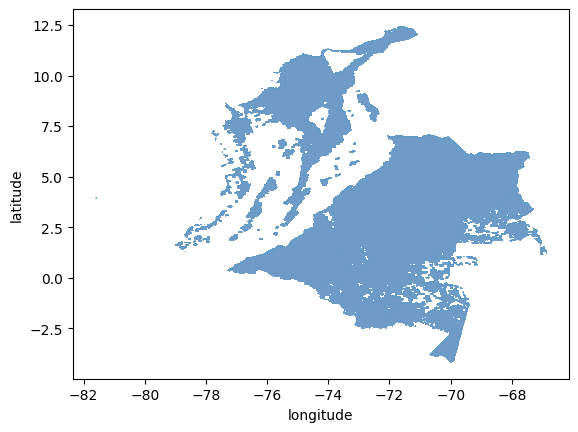

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',s=0.5)

In [ ]:
X= np.loadtxt('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv',skiprows=1,delimiter=',', usecols=(0,1,3)) # se carga el archivo .csv
X -= np.mean(X,axis=0) # Se deben normalizar las variables para que sean comparables# Se deben normalizar las variables para que sean comparables
X /= np.std(X,axis=0)

X.shape

(627438, 3)

<ipython-input-8-b01069e68e17>:6: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo


<Axes: xlabel='longitude', ylabel='latitude'>

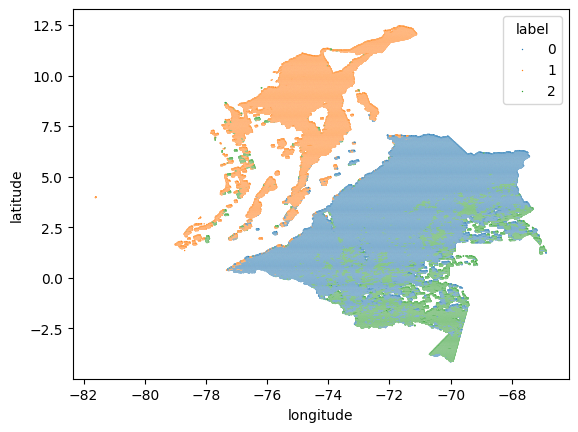

In [ ]:
alpha_star=3
kmeans = KMeans(n_clusters=alpha_star, random_state=1, n_init='auto').fit(X)
labe=kmeans.labels_
r['label']=labe
r
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo

<ipython-input-9-026067416397>:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagén para artículo


<Axes: xlabel='longitude', ylabel='latitude'>

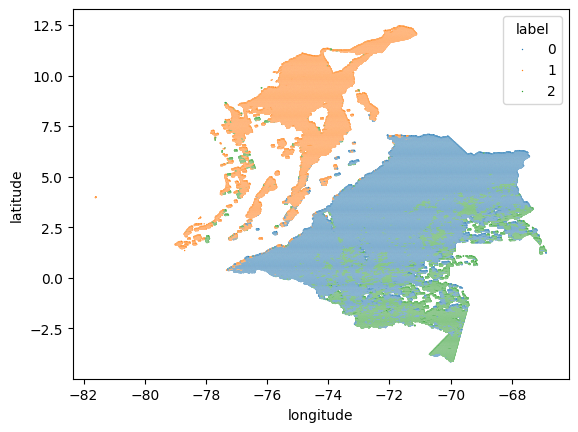

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagén para artículo

# Clasificación

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [ ]:
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
y=labe
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [ ]:
X_train

array([[-0.16624963, -0.13739523],
       [-0.26087047,  1.71998289],
       [-1.37051487, -0.42509844],
       ...,
       [ 0.41581191,  1.00918671],
       [-0.47591783,  0.98380113],
       [ 0.69107253,  1.04303415]])

In [ ]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [ ]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([0.5018, 0.4803]), tensor(0))


In [ ]:

# number of features (len of X cols)
input_dim = 2
# number of hidden layers
hidden_layers = 25
#hidden_layers2 = 125
# number of classes (unique of y)
output_dim = 4
class Network(nn.Module):
    def __init__(self,hidden_layers):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_layers)
        #self.linearh1=nn.Linear(hidden_layers,hidden_layers2)
        self.linear2 = nn.Linear(hidden_layers, output_dim)
    def forward(self, x):
        x = F.leaky_relu(self.linear1(x))
        #x = torch.sigmoid(self.linearh1(x))
        x = self.linear2(x)
        #x = F.softmax(x)
        return x


In [ ]:
epochs = 40
def run_epoch(epoch,ta,clf):
    criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
    optimizer = torch.optim.Adam(clf.parameters(), lr=ta)
    for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        # set optimizer to zero grad to remove previous epoch gradients
        optimizer.zero_grad()
        # forward propagation
        outputs = clf(inputs)
        loss = criterion(outputs, labels)
        # backward propagation
        loss.backward()
        # optimize
        optimizer.step()
        running_loss += loss.item()
      # display statistics
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')

In [ ]:
def test_val(clf):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy of the network on the {len(testdata)} test data: {100 * correct // total} %')
    return correct/total

In [ ]:
def parameters_train(ep,ta,hl):
    #nn_arch(hidden_layers)
    clf = Network(hl)
    epochs = ep
    lr=ta
    run_epoch(epoch,lr,clf)
    score=test_val(clf)
    return score

In [ ]:
#Se busca el mejor parámetro para la cantidad de capas ocultas
hd=np.arange(2,30,1)
epoch=40
lr=0.005
val_scores_hl=[]
batch_size = 500
cv=5
for hidden_layers in hd:
    print(hidden_layers)
    val_scores_hl_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_hl_cv.append(parameters_train(epoch,lr,hidden_layers))
    val_scores_hl.append(np.mean(val_scores_hl_cv))

2
[40,   841] loss: 0.02858
Accuracy of the network on the 207055 test data: 87 %
[40,   841] loss: 0.03019
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.03019
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.03052
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02934
Accuracy of the network on the 207055 test data: 88 %
3
[40,   841] loss: 0.02991
Accuracy of the network on the 207055 test data: 87 %
[40,   841] loss: 0.02758
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02597
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02997
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02672
Accuracy of the network on the 207055 test data: 88 %
4
[40,   841] loss: 0.02762
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02763
Accuracy of the network on the 207055 test data: 88 %
[40,   841] loss: 0.02988
Accuracy

In [ ]:
#Se encuentra la mejor cantidad de puntos en la capa oculta
ind = np.argmax(val_scores_hl)
hl_star = hd[ind] #Resultó ser 13
print('HL_star =', hl_star)

plt.plot(hd,val_scores_hl)
plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.9,1)
plt.ylim(0.9,1)
plt.xlabel('HL')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Se busca el mejor valor para la tasa de aprendizaje
epoch=40
lr=np.arange(1e-5,0.01,5e-4)
val_scores_lr=[]
batch_size = 500
cv=4
for i in lr:
    #print(clf.parameters)
    print(i)
    val_scores_lr_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_lr_cv.append(parameters_train(epoch,i,hl_star))
    val_scores_lr.append(np.mean(val_scores_lr_cv))

In [ ]:
ind = np.argmax(val_scores_lr)
lr_star = lr[ind]
print('LR_star =', lr_star)

plt.plot(lr,val_scores_lr)
plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.95,1)
plt.ylim(0.95,1)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

In [ ]:
# save the trained model
clf = Network(hl_star)
PATH = '/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/mymodel_prueba.pth'
torch.save(clf.state_dict(), PATH)

In [ ]:
# load the trained model
clf = Network()
clf.load_state_dict(torch.load(PATH))

In [ ]:
# mapa con la clasificación de resultado
#sns.scatterplot(x=inputs[:,0],y=inputs[:,1])#],hue='label',s=1,palette=sns.color_palette("tab10"))
y_pred=[]
for data in testloader:
    inputs, labels = data
    # calculate output by running through the network
    outputs = clf(inputs)
    # get the predictions
    __, predicted = torch.max(outputs.data, 1)
    y_pred.append(predicted)
# fig, ax = plt.subplots()
# for label in [0, 1,2,3]:
#     mask = (y_pred == label)
#     ax.scatter(inputs[mask, 0], inputs[mask, 1],s=0.3)
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

# Detección de anomalías

In [ ]:
X= np.loadtxt(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv',skiprows=1, usecols=(2,3,5),delimiter=',')
X

array([[  -4.165     ,  -69.995     , 1940.14050826],
       [  -4.155     ,  -70.005     , 1940.14050285],
       [  -4.135     ,  -69.965     , 1879.7114046 ],
       ...,
       [  12.425     ,  -71.605     , 1944.44151148],
       [  12.425     ,  -71.595     , 1944.02351529],
       [  12.425     ,  -71.585     , 1942.80969255]])

In [ ]:
def prepData(processed_data,iSplit=0.5):
    # gaia_vars=['phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag']
    # var0=(igaia_data[gaia_vars[0]]-idist.distmod).value
    # var1=(igaia_data[gaia_vars[1]]-idist.distmod).value
    # var2=(igaia_data[gaia_vars[2]]-idist.distmod).value
    # var3=igalcen.x.value
    # var4=igalcen.y.value
    # var5=igalcen.z.value
    # var6=igalcen.v_x.value
    # var7=igalcen.v_y.value
    # var8=igalcen.v_z.value

    #processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = processed_data.T
    # processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]
    processed_data_raw = processed_data.copy()

    #normalize the data
    processed_data -= np.mean(processed_data,axis=0)
    processed_data /= np.std(processed_data,axis=0)
    processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]

    #pytorch the layer
    tprocessed_data = torch.tensor(processed_data).float()
    processed_data_raw = processed_data_raw[~torch.any(tprocessed_data.isnan(),dim=1)]
    #galcen_clean       = igalcen[~torch.any(tprocessed_data.isnan(),dim=1)]
    n_samples=processed_data.shape[0]
    indices = np.arange(n_samples)
    #split
    X_train, X_test, Y_train, Y_test = train_test_split(processed_data, indices, test_size=iSplit)
    maxindex       = int(len(processed_data)*iSplit)
    trainset       = torch.tensor(X_train).float()
    trainset       = trainset[~torch.any(trainset.isnan(),dim=1)]
    testset        = torch.tensor(X_test).float()
    testset        = testset[~torch.any(testset.isnan(),dim=1)]
    print(processed_data_raw.shape,testset.shape,trainset.shape)
    return testset,trainset,processed_data_raw,tprocessed_data, Y_train, Y_test #,galcen_clean

#btestset,btrainset,bprocessed_data_raw,btprocessed_data,bgalcen_clean=prepData(gaia_data,dist,galcen)
btestset,btrainset,bprocessed_data_raw,btprocessed_data,index_train,index_test=prepData(X)

(494254, 3) torch.Size([247127, 3]) torch.Size([247127, 3])


In [ ]:
#autoencoder para que la red neuronal aprenda las características más relevantes de los datos
class MLP(nn.Module):
    def __init__(self,n_inputs,n_outputs):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 20),
            nn.LeakyReLU(),
            nn.Linear(20, 6),
            nn.ReLU(),
            nn.Linear(6, 2),
            nn.ReLU(),
            nn.Linear(2, 6),
            nn.ReLU(),
            nn.Linear(6, 20),
            nn.ReLU(),
            nn.Linear(20, n_outputs),
        )

    def forward(self, x):
        x = self.layers(x)
        return x

def train(x,y,net,loss_func,opt,sched,nepochs):
    net.train(True)
    for epoch in range(nepochs):
        prediction = net(x)
        opt.zero_grad()
        loss = loss_func(prediction,y)
        loss.backward()
        opt.step()
        if epoch % 500 == 0:
            print('[%d] loss: %.4f ' % (epoch + 1, loss.item()  ))
    #sched.step()
    return

basicmodel     = MLP(btrainset.shape[1],1)#btrainset.shape[1])
optimizer = torch.optim.Adam(basicmodel.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1, last_epoch=-1, verbose=False)
loss_fn   =  nn.MSELoss(reduction='sum')

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train(btrainset,btrainset[:,2:],basicmodel,loss_fn,optimizer,scheduler,5001)

[1] loss: 246820.1562 
[501] loss: 65.8551 
[1001] loss: 2984.8708 
[1501] loss: 10.4928 
[2001] loss: 17.3126 
[2501] loss: 5.4476 
[3001] loss: 8.9664 
[3501] loss: 4.0144 
[4001] loss: 6.3598 
[4501] loss: 3.0376 
[5001] loss: 3.8417 


In [ ]:
btrainset.shape

torch.Size([247127, 3])

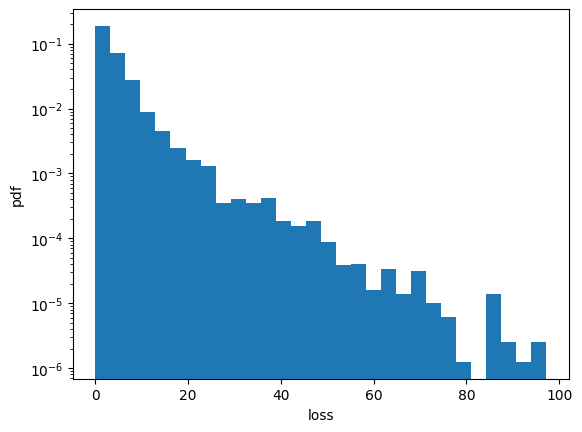

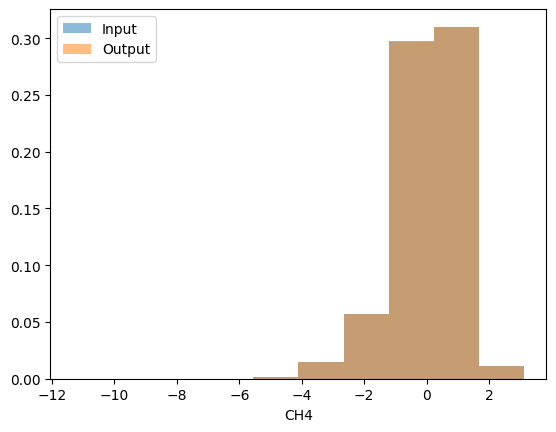

In [ ]:
basicmodel.train(False)
boutput=basicmodel(btestset)
btestloss=torch.sum((btestset-boutput)**2,axis=1)
plt.hist(btestloss[btestloss < 100].detach().numpy(),density=True,bins=30)
plt.yscale('log')
plt.xlabel('loss')
plt.ylabel('pdf')
plt.show()

varlabels=['longitude','latitude','CH4']#['Mag','B-Mag','R-Mag','x','y','z','vx','vy','vz']
_,bins,_=plt.hist(btestset[:,2].detach().numpy(),density=True,alpha=0.5,label='Input')
plt.hist(boutput.detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
plt.xlabel(varlabels[2])
plt.legend()
# fig, ax = plt.subplots(3, 3, figsize=(20, 20))
# for var in range(btestset.shape[1]):
#     _,bins,_=ax[var//3,var % 3].hist(btestset[:,var].detach().numpy(),density=True,alpha=0.5,label='Input')
#     ax[var//3,var % 3].hist(boutput [:,var].detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
#     ax[var//3,var % 3].set_xlabel(varlabels[var])
#     ax[var//3,var % 3].legend()

(247127,) (247127,)


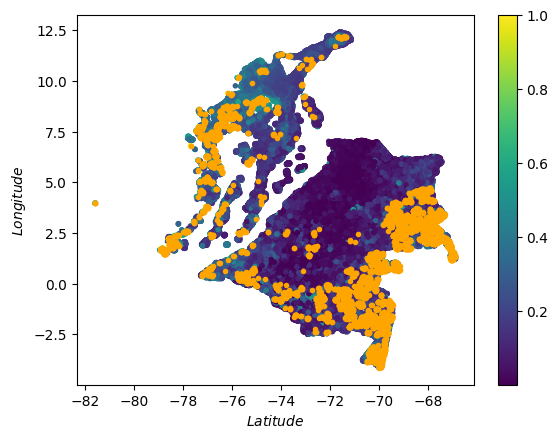

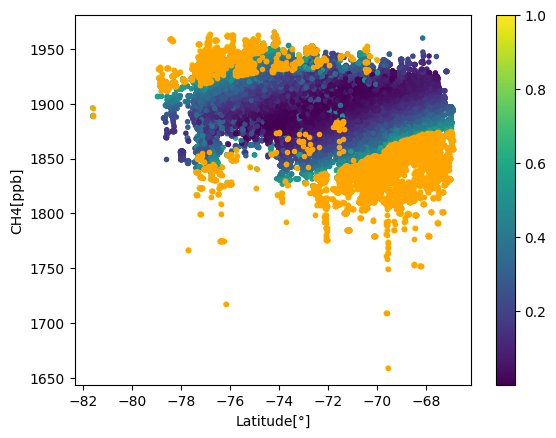

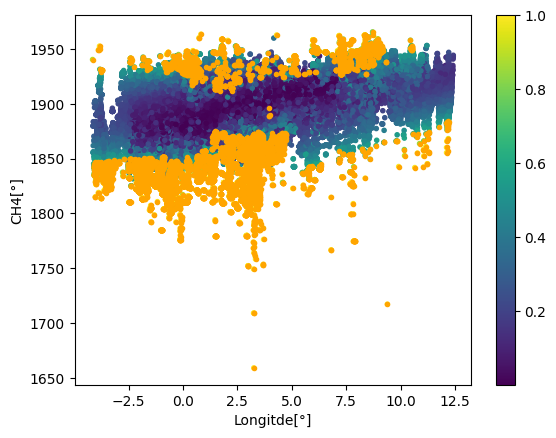

In [ ]:
def plotAnomaly(iCut,iRaw,iLoss,i_test,maxlosscolor=20):
    loss = np.minimum(iLoss,maxlosscolor)
    anomalies=(iLoss > iCut)
    #baseidex=len(iRaw)-len(iLoss)
    btestdata_raw = iRaw[i_test]
    anomaly_raw  = btestdata_raw[anomalies]
    #btestgalcen   = igalcen[baseidex:]#
    #anomaly_galcen = btestgalcen[anomalies]#
    loss = loss/np.max(loss)
    if maxlosscolor != 20:
        loss=np.ones(loss.shape)
    print(loss.shape,btestdata_raw[:,2].shape)
    scat=plt.scatter(btestdata_raw[:,1],btestdata_raw[:,0], marker='.',c=loss,cmap="viridis")
    plt.plot(anomaly_raw[:,1],anomaly_raw[:,0], marker='.', linestyle='none',c='orange')
    plt.xlabel('$Latitude$')
    plt.ylabel('$Longitude$')
    #plt.ylim(15,0)
    #plt.xlim(1,-5)
    plt.colorbar(scat)
    plt.show()

    scat=plt.scatter(btestdata_raw[:,1],btestdata_raw[:,2],c=loss, marker='.',cmap="viridis")
    plt.plot(anomaly_raw[:,1],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
    plt.xlabel("Latitude[°]")
    plt.ylabel("CH4[ppb]")
    plt.colorbar(scat)
    plt.show()

    scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,2],c=loss, marker='.', cmap="viridis")
    plt.plot(anomaly_raw[:,0],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
    plt.xlabel("Longitde[°]")
    plt.ylabel("CH4[°]")
    plt.colorbar(scat)
    plt.show()

    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,7],c=loss, marker='.', cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,7], marker='.', linestyle='none',c='orange')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vy[pc]")
    # plt.colorbar(scat)
    # plt.show()

    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,8],c=loss, marker='.',cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,8], marker='.', linestyle='none')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vz[pc]")
    # plt.show()

    # print(len(btestdata_raw),len(iRaw),len(igalcen),len(btestgalcen))
    # H = gp.Hamiltonian(milky_way)
    # w0_anom = gd.PhaseSpacePosition(anomaly_galcen.cartesian)
    # orbits_anom = H.integrate_orbit(w0_anom, dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)
    # w0_all  = gd.PhaseSpacePosition(bgalcen_clean[1==1].cartesian)
    # orbits_all  = H.integrate_orbit(w0_all,  dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)

    # zmax_all = orbits_all.zmax(approximate=True)
    # zmax_anom = orbits_anom.zmax(approximate=True)
    # print("ZMax mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 10, 50)
    # plt.hist(zmax_all.value, bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel(r" zmax" + " [{0:latex}]".format(zmax_all.unit))
    # plt.show()

    # zmax_all  = orbits_all.eccentricity()
    # zmax_anom = orbits_anom.eccentricity()
    # print("Ecc mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 3, 50)
    # plt.hist(zmax_all.value,  bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel('Eccentricity')
    # plt.show()


plotAnomaly(12,bprocessed_data_raw,btestloss.detach().numpy(),index_test)#,bgalcen_clean)

In [ ]:
#Dividir los puntos anomalos por altos o bajos
#Relacionar con el uso de la tierra en puntos anomalos

# Suplemental
Se debe correr la sección alistamiento de datos hastala línea donde se carga df_s y se muestra un mapa

In [ ]:
encoded_df45=encoded_df[(encoded_df['Leyenda_1_4. Áreas húmedas']==True)+(encoded_df['Leyenda_1_5. Superficies de agua']==True)]#tabla para eliminar el glint en la plataforma continental

In [ ]:
encoded_df45

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,groupb
217,218.0,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2020_mediana_07042021,None,SI,1,5,51,512,...,False,False,False,False,False,False,False,False,True,0
249,250.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
255,256.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
269,270.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,2,4,41,411,...,False,False,False,False,False,False,False,True,False,0
338,339.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,None,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393434,393435.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393435,393436.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393450,393451.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393453,393454.0,511,5.1.1. Ríos,Landsat_2020_mediana_07042021,None,SI,1,5,51,511,...,False,False,False,False,False,False,False,False,True,0


In [ ]:
#df_g es el promedio de todos los año filtrado sin cuerpo de agua para evitar el glint
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')
#df_g=df_s[df_s['Leyenda_1_4. Áreas húmedas'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]#.plot(x='longitude',y='latitude',column='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
#df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')
#df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
df_s

,latitude,longitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,1.693677e+12,1940.140508
1,-4.155,-70.005,1.693677e+12,1940.140503
2,-4.145,-70.015,1.708235e+12,1909.925894
3,-4.145,-70.005,1.708235e+12,1909.925963
4,-4.145,-69.995,1.722793e+12,1879.711295
...,...,...,...,...
627433,12.445,-71.655,1.705076e+12,1949.046718
627434,12.445,-71.645,1.705311e+12,1949.149711
627435,12.445,-71.635,1.705231e+12,1949.489883
627436,12.455,-71.675,1.704910e+12,1947.918769


In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta
df_s

,Unnamed: 0,latitude,longitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,0,-4.165,-69.995,1.693677e+12,1940.140508,[-69.995],[-4.165],"[-69.995, -4.165]","POLYGON ((-70.00500000000001 -4.175, -70.00500...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,-4.155,-70.005,1.693677e+12,1940.140503,[-70.005],[-4.155],"[-70.005, -4.155]","POLYGON ((-70.015 -4.165, -70.015 -4.145000000...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,-4.145,-70.015,1.708235e+12,1909.925894,[-70.015],[-4.1450000000000005],"[-70.015, -4.1450000000000005]","POLYGON ((-70.025 -4.155, -70.025 -4.135000000...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
3,3,-4.145,-70.005,1.708235e+12,1909.925963,[-70.005],[-4.1450000000000005],"[-70.005, -4.1450000000000005]","POLYGON ((-70.015 -4.155, -70.015 -4.135000000...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
4,4,-4.145,-69.995,1.722793e+12,1879.711295,[-69.995],[-4.1450000000000005],"[-69.995, -4.1450000000000005]","POLYGON ((-70.00500000000001 -4.155, -70.00500...",0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627433,627433,12.445,-71.655,1.705076e+12,1949.046718,[-71.655],[12.445],"[-71.655, 12.445]","POLYGON ((-71.665 12.435, -71.665 12.455, -71....",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
627434,627434,12.445,-71.645,1.705311e+12,1949.149711,[-71.645],[12.445],"[-71.645, 12.445]","POLYGON ((-71.655 12.435, -71.655 12.455, -71....",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
627435,627435,12.445,-71.635,1.705231e+12,1949.489883,[-71.635],[12.445],"[-71.635, 12.445]","POLYGON ((-71.64500000000001 12.435, -71.64500...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
627436,627436,12.455,-71.675,1.704910e+12,1947.918769,[-71.675],[12.455],"[-71.675, 12.455]","POLYGON ((-71.685 12.445, -71.685 12.465, -71....",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
l_in=list(encoded_df45.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df45[i]=encoded_df[i]*encoded_df['SHAPE_Area']
#df_s.loc[:,l_in]=None
#df_s['Leyenda_1_4. Áreas húmedas'][0]

/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered_pausa_349827.csv')


In [ ]:
for j in df_s.index[349827:]:
    #print(j)
    f=encoded_df45[df_s['geometry'][j].intersects(encoded_df45['geometry'])]
    f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    if not len(f1)==0:
      for i in l_in:
        df_s.loc[j, i]=f1[i].iloc[0].copy()
    if j%5e4==0:
      print(j)

350000
400000
450000
500000
550000
600000


In [ ]:
df_g=df_s[df_s['Leyenda_1_5. Superficies de agua'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]

<Axes: xlabel='longitude', ylabel='latitude'>

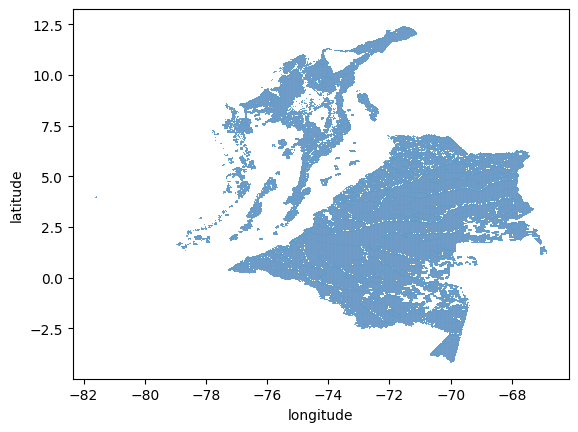

In [ ]:
sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='label',s=1,palette=sns.color_palette("tab10"))

In [ ]:
df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')

In [ ]:
df_g.dtypes.head(60)

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
latitude,float64
longitude,float64
time,float64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
coordinate_x,object
coordinate_y,object
coordinates,object
geometry,object


In [ ]:
#Correr desde acá 11/11/24
df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')
df_g['coordinate_x']=df_g['longitude'].apply(lambda x: [x])
df_g['coordinate_y']=df_g['latitude'].apply(lambda x: [x])
df_g['coordinates']=df_g['coordinate_x']+df_g['coordinate_y']
df_g
df_g.coordinates

,coordinates
0,"[-69.995, -4.165]"
1,"[-70.005, -4.155]"
2,"[-69.965, -4.135]"
3,"[-69.955, -4.135]"
4,"[-69.94500000000001, -4.135]"
...,...
494249,"[-71.58500000000001, 12.415]"
494250,"[-71.575, 12.415]"
494251,"[-71.605, 12.425]"
494252,"[-71.595, 12.425]"


In [ ]:
df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28


In [ ]:
df_completo['coordinate_x']=df_completo['longitude'].apply(lambda x: [x])
df_completo['coordinate_y']=df_completo['latitude'].apply(lambda x: [x])
df_completo['coordinates']=df_completo['coordinate_x']+df_completo['coordinate_y']
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]"
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]"
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]"
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]"
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]"
...,...,...,...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]"
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.44500000000001, 4.525]"
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]"
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]"


In [ ]:
#df_completo.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo

KeyboardInterrupt: 

In [ ]:
#df_completo.coordinates.to_numpy()[0]
df_completo_ng=df_completo[df_completo.coordinates.isin(df_g.coordinates)]#Se filtran los datos para saber cuáles son los válidos sin glint
df_completo_ng


In [ ]:
df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')

In [ ]:
#df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')
#df_completo.coordinates.isin(df_g.coordinates)

In [ ]:
df_completo_ng.dtypes

,0
id,object
longitude,float64
latitude,float64
time,int64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
date,object
coordinate_x,object
coordinate_y,object
coordinates,object


In [ ]:
df_completo_ng=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo_ng['date']=pd.to_datetime(df_completo_ng['date'])
#df_comleto_ng['year']=df_completo_ng['date'].dt.year
df_2020=df_completo_ng[df_completo_ng.date.dt.year==2020]
df_2020.groupby(['longitude','latitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020.csv')
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421
307151,-67.315,3.375,1.580923e+12,1851.070163
307152,-67.315,3.385,1.580923e+12,1851.070189
307153,-67.315,3.435,1.577987e+12,1835.456439
